## Module 2: Machine Learning for Regression

This module consists of .

### Part 1: Data Preparation

In [1]:
# get car price data
!wget 'https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/master/chapter-02-car-price/data.csv'

--2026-09-19 14:56:04--  https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/master/chapter-02-car-price/data.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.110.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1475504 (1.4M) [text/plain]
Saving to: ‘data.csv.1’

data.csv.1          100%[===================>]   1.41M  --.-KB/s    in 0.01s   

2026-09-19 14:56:04 (94.4 MB/s) - ‘data.csv.1’ saved [1475504/1475504]



In [41]:
# check the data
import pandas as pd
import numpy as np

df = pd.read_csv('data.csv')
df.head()

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


In [42]:
df.dtypes

Make                     str
Model                    str
Year                   int64
Engine Fuel Type         str
Engine HP            float64
Engine Cylinders     float64
Transmission Type        str
Driven_Wheels            str
Number of Doors      float64
Market Category          str
Vehicle Size             str
Vehicle Style            str
highway MPG            int64
city mpg               int64
Popularity             int64
MSRP                   int64
dtype: object

In [43]:
# rewrite column names lowercase with no space (to be able to use in dot form)
df.columns = df.columns.str.lower().str.replace(' ', '_')

# check string columns and make their content lowercase with no space
#df['make'].str.lower().str.replace(' ', '_')
str_cols = list(df.dtypes[df.dtypes == 'str'].index)
for col in str_cols:
    df[col] = df[col].str.lower().str.replace(' ', '_')

df.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,bmw,1_series_m,2011,premium_unleaded_(required),335.0,6.0,manual,rear_wheel_drive,2.0,"factory_tuner,luxury,high-performance",compact,coupe,26,19,3916,46135
1,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,convertible,28,19,3916,40650
2,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,28,20,3916,36350
3,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,coupe,28,18,3916,29450
4,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,28,18,3916,34500


### Part 2: Exploratory Data Analysis

In [44]:
# check column statistics
for col in df.columns:
    print(col)
    print(df[col].unique()[:5]) # 5 unique values
    print(df[col].nunique()) # number of unique values
    print()

make
<StringArray>
['bmw', 'audi', 'fiat', 'mercedes-benz', 'chrysler']
Length: 5, dtype: str
48

model
<StringArray>
['1_series_m', '1_series', '100', '124_spider', '190-class']
Length: 5, dtype: str
914

year
[2011 2012 2013 1992 1993]
28

engine_fuel_type
<StringArray>
[   'premium_unleaded_(required)',               'regular_unleaded',
 'premium_unleaded_(recommended)',       'flex-fuel_(unleaded/e85)',
                         'diesel']
Length: 5, dtype: str
10

engine_hp
[335. 300. 230. 320. 172.]
356

engine_cylinders
[ 6.  4.  5.  8. 12.]
9

transmission_type
<StringArray>
['manual', 'automatic', 'automated_manual', 'direct_drive', 'unknown']
Length: 5, dtype: str
5

driven_wheels
<StringArray>
['rear_wheel_drive', 'front_wheel_drive', 'all_wheel_drive',
 'four_wheel_drive']
Length: 4, dtype: str
4

number_of_doors
[ 2.  4.  3. nan]
3

market_category
<StringArray>
['factory_tuner,luxury,high-performance',
                    'luxury,performance',
               'luxury,high-pe

In [45]:
# check missing values in each column
df.isnull().sum()

make                    0
model                   0
year                    0
engine_fuel_type        3
engine_hp              69
engine_cylinders       30
transmission_type       0
driven_wheels           0
number_of_doors         6
market_category      3742
vehicle_size            0
vehicle_style           0
highway_mpg             0
city_mpg                0
popularity              0
msrp                    0
dtype: int64

<Axes: xlabel='msrp', ylabel='Count'>

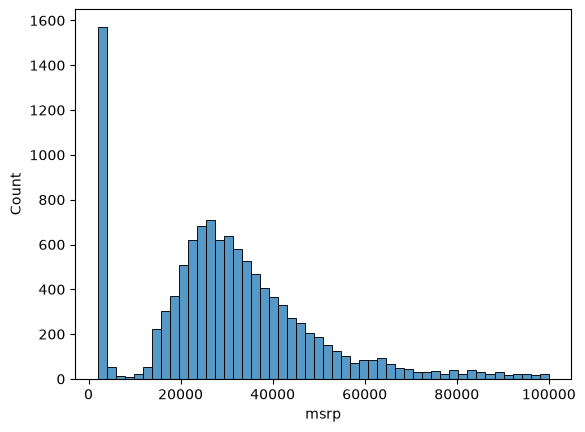

In [46]:
# check statistics with visualization
import matplotlib.pyplot as plt
import seaborn as sns

# added to make sure plots are seen inline
%matplotlib inline 

#check price distribution

# long tail distribution - data is concentrated on a narrow area
#sns.histplot(df.msrp, bins=50)

# zoom in on the long tail data
sns.histplot(df.msrp[df.msrp < 100000], bins=50)

Apply log transformations to numeric data before feeding it to a model to reduce skewness, handle massive ranges in scale, and linearize non-linear relationships. While `np.log(x)` calculates `ln(x)` and fails at zero or tiny numbers, `np.log1p(x)` calculates `ln(1+x)` accurately and avoids precision errors, making it ideal for datasets containing zeros.

Sample Data: [0, 1, 10, 1000, 100000]
Log Transf: [ 0.          0.69314718  2.39789527  6.90875478 11.51293546]


<Axes: xlabel='msrp', ylabel='Count'>

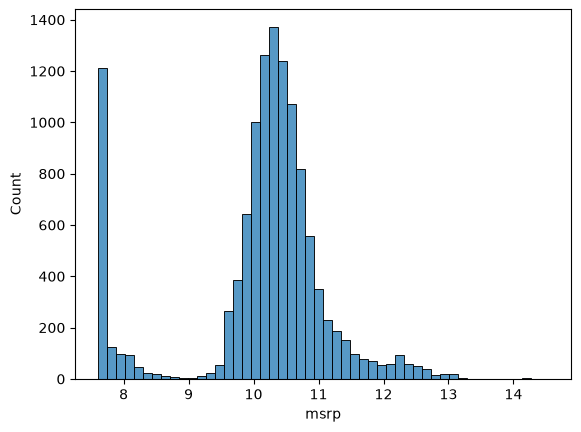

In [47]:
# perform log transformation on sample data
sample = [0, 1, 10, 1000, 100000]
print("Sample Data:", sample)
print("Log Transf:", np.log1p(sample))

# perform log transformation on price data
price_logs = np.log1p(df.msrp)
sns.histplot(price_logs, bins=50) 

Applying log transformation returns normal distribution, which helps model work better.

### Part 3: Setting Up Validation Framework

To train the model, data is splitted into three parts: train, validation, test

In [48]:
# split data and get the size of each set
n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

print("Total size:", n)
print(f"Val, Test, Train: ({n_val}, {n_test}, {n_train})")

Total size: 11914
Val, Test, Train: (2382, 2382, 7150)


In [49]:
# check how to use iloc
df.iloc[[100, 2]]

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
100,nissan,240sx,1997,regular_unleaded,155.0,4.0,manual,rear_wheel_drive,2.0,performance,compact,coupe,26,19,2009,4107
2,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,28,20,3916,36350


In [50]:
# shuffle data to avoid any issues about it
idx = np.arange(n)
np.random.seed(2)
np.random.shuffle(idx)

# separate data sets (without shuffle)
#df_train = df.iloc[:n_train]
#df_val = df.iloc[n_train:n_train+n_val]
#df_test = df.iloc[n_train+n_val:]

# separate data sets after shuffle and reset index
df_train = df.iloc[idx[:n_train]].reset_index(drop=True)
df_val = df.iloc[idx[n_train:n_train+n_val]].reset_index(drop=True)
df_test = df.iloc[idx[n_train+n_val:]].reset_index(drop=True)

# get y variable as price column for training (using log transformations)
y_train = np.log1p(df_train.msrp.values) # get as np array and not series using 'values'
y_val = np.log1p(df_val.msrp.values)
y_test = np.log1p(df_test.msrp.values)

# remove price from data to avoid having it as a training feature
del df_train['msrp']
del df_val['msrp']
del df_test['msrp']

# check out data and y size for each set
print(f"Train, Val, Test: ({len(df_train)}, {len(df_val)}, {len(df_test)})")
print(f"y_train, y_val, y_test: ({len(y_train)}, {len(y_val)}, {len(y_test)})")

# check out train data
df_train.head(3)

Train, Val, Test: (7150, 2382, 2382)
y_train, y_val, y_test: (7150, 2382, 2382)


,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity
0,chevrolet,cobalt,2008,regular_unleaded,148.0,4.0,manual,front_wheel_drive,2.0,NaN,compact,coupe,33,24,1385
1,toyota,matrix,2012,regular_unleaded,132.0,4.0,automatic,front_wheel_drive,4.0,hatchback,compact,4dr_hatchback,32,25,2031
2,subaru,impreza,2016,regular_unleaded,148.0,4.0,automatic,all_wheel_drive,4.0,hatchback,compact,4dr_hatchback,37,28,640


### Part 4: Linear Regression

Linear regression predicts a numerical value using a weighted sum of features. For the full dataset:

$g(X) \approx y$, where $X$ is the feature matrix, $y$ is the target, and $g$ is the model. For a single observation $x_i$:

$g(x_i) \approx y_i$, where $x_i$ is one row of $X$ containing all features of observation $i$, and $y_i$ is its target value. It ca also be written as:

$g(x_i)=w_0+\sum_{j=1}^{n}w_jx_{ij}=w_0+x_i^Tw$

* $x_i$: observation $i$
* $x_{ij}$: feature $j$ of observation $i$
* $w_0$: bias/intercept
* $w_j$: weight of feature $j$
* $w_jx_{ij}$: contribution of feature $j$

So: $\text{prediction}=\text{bias}+\text{weighted sum of features}$

$w_j>0$ increases the prediction; $w_j<0$ decreases it. If the target is transformed with:

$y_{\log}=\log(1+y)$

convert predictions back with:

$y=e^{\hat y_{\log}}-1$

i.e. `log1p(y)` ↔ `expm1(y_pred)`.

In [51]:
# pick an observation (i = 10)
df_train.iloc[10]

make                                 rolls-royce
model                     phantom_drophead_coupe
year                                        2015
engine_fuel_type     premium_unleaded_(required)
engine_hp                                  453.0
engine_cylinders                            12.0
transmission_type                      automatic
driven_wheels                   rear_wheel_drive
number_of_doors                              2.0
market_category        exotic,luxury,performance
vehicle_size                               large
vehicle_style                        convertible
highway_mpg                                   19
city_mpg                                      11
popularity                                    86
Name: 10, dtype: object

In [52]:
def linear_regression(x_i):
    """
    Predicts the target value for one observation using linear regression.

    The prediction is calculated as:
        prediction = w_0 + w[0]*x_i[0] + ... + w[n-1]*x_i[n-1]

    Parameters:
        x_i (list): Feature values for one observation.

    Returns:
        float: Predicted target value.
    """
    n = len(x_i)
    pred = w_0
    for j in range(n):
        pred += w[j] * x_i[j]

    return pred

In [53]:
# define feature matrix containin engine_hp, city_mpg and popularity for a single observation (i = 10)
i = 10
x_i = list(map(int, [df_train.iloc[i].engine_hp, df_train.iloc[i].city_mpg, df_train.iloc[i].popularity]))

w_0 = 7.17
w = [0.01, 0.04, 0.002]

y_i = linear_regression(x_i)

print(f"For observation {i}: Features x_{i} = {x_i}")
print("Prediction (log transformed):", y_i, " == ", np.log1p(np.expm1(y_i)))
print("Prediction:", np.expm1(y_i))

For observation 10: Features x_10 = [453, 11, 86]
Prediction (log transformed): 12.312  ==  12.312
Prediction: 222347.2221101062


### Part 5: Linear Regression Vector Form

For one observation:

$g(x_i)=w_0+\sum_{j=1}^{n}x_{ij}w_j$

The sum is a **dot product**, so:

$g(x_i)=w_0+x_i^Tw$

where:

* $x_i$ = feature vector of observation $i$
* $w$ = vector of feature weights
* $x_i^Tw$ = dot product of features and weights
* $w_0$ = bias

To include the bias inside the dot product, add a fictional feature $x_{i0}=1$ and then:

$x_i=[1,x_{i1},...,x_{in}]$ and, $w=[w_0,w_1,...,w_n]$

so the whole prediction becomes simply:

$g(x_i)=x_i^Tw$

For all observations, stack the feature vectors into matrix $X$:

$
X=
\begin{bmatrix}
1 & x_{11} & \cdots & x_{1n}\\
1 & x_{21} & \cdots & x_{2n}\\
\vdots & \vdots & & \vdots\\
1 & x_{m1} & \cdots & x_{mn}
\end{bmatrix}
$

Then predictions for all observations are obtained at once: $\boxed{Xw \approx y}$

So the progression is: $\text{sum} \rightarrow \text{dot product} \rightarrow \text{matrix-vector multiplication}$

In [54]:
def dot(x_i, w):
    """
    Computes the dot product between a feature vector and a weight vector.

    Parameters:
        x_i (list): Feature values for one observation.
        w (list): Corresponding model weights.

    Returns:
        float: Sum of x_i[j] * w[j].
    """
    n = len(x_i)
    res = 0.0
    for j in range(n):
        res += x_i[j] * w[j]
    return res

def linear_regression_vec(x_i, w):
    """
    Predicts the target for one observation using vector-form linear regression.

    A constant 1 is added to x_i so the bias term is included in the dot product:
        prediction = [1, x1, ..., xn] · [w0, w1, ..., wn]

    Parameters:
        x_i (list): Feature values for one observation.
        w (list): Model weights including the bias w0.

    Returns:
        float: Predicted target value.
    """
    x_i = [1] + x_i
    return dot(x_i, w)

In [55]:
# define feature matrix containin engine_hp, city_mpg and popularity for a single observation (i = 10)
w_new = [w_0] + w
y_i = linear_regression_vec(x_i, w_new)

print(f"For observation {i}: Features x_{i} = {x_i}")
print(f"Weights: {w_new}")
print("Prediction (log transformed):", y_i, " == ", np.log1p(np.expm1(y_i)))
print("Prediction:", np.expm1(y_i))

For observation 10: Features x_10 = [453, 11, 86]
Weights: [7.17, 0.01, 0.04, 0.002]
Prediction (log transformed): 12.312  ==  12.312
Prediction: 222347.2221101062


In [56]:
def linear_regression(X, w):
    """
    Predicts target values for all observations using matrix-form linear regression.

    Parameters:
        X (ndarray): Feature matrix, including a column of 1s for the bias term.
        w (ndarray): Weight vector, including the bias weight w0.

    Returns:
        ndarray: Predicted target values for all observations.
    """
    return X.dot(w)

# define feature matrix containin engine_hp, city_mpg and popularity for multiple observations (1, 2, 10)
x_1  = [1, 148, 24, 1385]
x_2  = [1, 132, 25, 2031]
x_10 = [1, 453, 11, 86]

X = np.array([x_1, x_2, x_10])
y = linear_regression(X, w_new)

print("Feature matrix X:\n", X)
print(f"Weights: {w_new}")
print("Predictions (log transformed):", y, " == ", np.log1p(np.expm1(y)))
print("Predictions:", np.expm1(y))

Feature matrix X:
 [[   1  148   24 1385]
 [   1  132   25 2031]
 [   1  453   11   86]]
Weights: [7.17, 0.01, 0.04, 0.002]
Predictions (log transformed): [12.38  13.552 12.312]  ==  [12.38  13.552 12.312]
Predictions: [237992.82334859 768348.51018973 222347.22211011]


### Part 6: Training a Linear Regression Model

Predictions need to be close to the targets: $Xw \approx y$

If $X$ were square and invertible:

$w=X^{-1}y$

But $X$ is usually rectangular, so $X^{-1}$ does not exist. So, multiply both sides by $X^T$:

$X^TXw=X^Ty$

$X^TX$ is the **Gram matrix** and is square. Therefore:

$(X^TX)^{-1}X^TXw=(X^TX)^{-1}X^Ty$

Since:

$(X^TX)^{-1}X^TX=I$

we get the **normal equation**:

$\boxed{w=(X^TX)^{-1}X^Ty}$

where:

* $X$ = feature matrix
* $y$ = target vector
* $w$ = learned weights
* $X^T$ = transpose of $X$
* $X^TX$ = Gram matrix
* $(X^TX)^{-1}$ = inverse of the Gram matrix

To include the bias $w_0$, add a column of ones to $X$ before applying the formula.
The result gives the weights that make $Xw$ as close as possible to $y$.

In [57]:
# define feature matrix containin engine_hp, city_mpg and popularity for multiple observations
X = [
    [148, 24, 1385],
    [132, 25, 2031],
    [453, 11, 86],
    [158, 24, 185],
    [172, 25, 201],
    [413, 11, 86],
    [38,  54, 185],
    [142, 25, 431],
    [453, 31, 86],
]
X_raw = np.array(X)
# add ones column for dot product
ones = np.ones(X_raw.shape[0])
X = np.column_stack([ones, X_raw])

# assume sample predictions
y = [10000, 20000, 15000, 20050, 10000, 20000, 15000, 25000, 12000]

# find weights column
XTX = X.T.dot(X)
XTX_inv = np.linalg.inv(XTX)
w_full = XTX_inv.dot(X.T).dot(y)

w_0 = w_full[0]
w = w_full[1:]

print("bias: ", w_0)
print("w: ", w)

bias:  25844.754055766833
w:  [ -16.08906468 -199.47254894   -1.22802883]


In [58]:
def train_linear_regression(X, y):
    """
    Trains a linear regression model using the normal equation.

    A column of ones is added to X to learn the bias term w0.
    The weights are calculated as:
        w = (X.T @ X)^(-1) @ X.T @ y

    Parameters:
        X (ndarray): Feature matrix.
        y (ndarray): Target values.

    Returns:
        tuple:
            w0 (float): Bias/intercept.
            w (ndarray): Weights for the input features.
    """
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]

bias, w = train_linear_regression(X_raw, y)
print("bias: ", bias)
print("w: ", w)

bias:  25844.754055766833
w:  [ -16.08906468 -199.47254894   -1.22802883]


### Part 7: Car Price Baseline Model


In [59]:
df_train.dtypes

make                     str
model                    str
year                   int64
engine_fuel_type         str
engine_hp            float64
engine_cylinders     float64
transmission_type        str
driven_wheels            str
number_of_doors      float64
market_category          str
vehicle_size             str
vehicle_style            str
highway_mpg            int64
city_mpg               int64
popularity             int64
dtype: object

X_train shape: (7150, 5)
y_train shape: (7150,)
y_pred shape: (7150,)
bias:  7.927257388070037
w:  [ 9.70589522e-03 -1.59103494e-01  1.43792133e-02  1.49441072e-02
 -9.06908672e-06]


<Axes: ylabel='Count'>

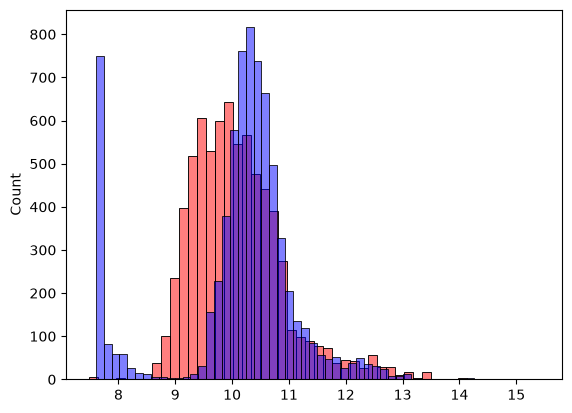

In [60]:
# build baseline model on selected numeric features
base = ['engine_hp', 'engine_cylinders', 'highway_mpg', 'city_mpg', 'popularity']

X_train = df_train[base].fillna(0).values
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

# get the weights
w_0, w = train_linear_regression(X_train, y_train)
y_pred = w_0 + X_train.dot(w)
print("y_pred shape:", y_pred.shape)
print("bias: ", w_0)
print("w: ", w)

# plot actual and predicted prices
sns.histplot(y_pred, color='red', alpha=0.5, bins=50)
sns.histplot(y_train, color='blue', alpha=0.5, bins=50)

### Part 8: RMSE (Root Mean Squared Error)

RMSE measures how far predictions are from the true values.

$\text{RMSE}=
\sqrt{
\frac{1}{m}
\sum_{i=1}^{m}
(\hat y_i-y_i)^2
}$

where:

- $y_i$ = actual value
- $\hat y_i$ = predicted value
- $m$ = number of observation

Smaller RMSE means better predictions. Because errors are squared, large mistakes are penalized more heavily. RMSE is also in the same unit as the target variable.

In [61]:
def rmse(y, y_pred):
    """
    Computes the Root Mean Squared Error (RMSE) between actual and predicted values.

    Parameters:
        y (ndarray): Actual target values.
        y_pred (ndarray): Predicted target values.

    Returns:
        float: RMSE value.
    """
    return np.sqrt(((y - y_pred) ** 2).mean())

print("RMSE: ", rmse(y_train, y_pred))

RMSE:  0.7554192603920132


### Part 9: Validating the Model

Model needsto be evaluated on validation data, and not the same data used for training.

Process:

$X_{\text{train}} \rightarrow \text{train model} \rightarrow w$

$X_{\text{val}} \rightarrow \text{predict} \rightarrow \text{RMSE}(y_{\text{val}}, \hat y)$

The validation set shows how well the model performs on unseen data. Use the same feature-preparation steps for training and validation data.

In [62]:
def prepare_x(df, base):
    return df[base].fillna(0).values

# build baseline model on selected numeric features
base = ['engine_hp', 'engine_cylinders', 'highway_mpg', 'city_mpg', 'popularity']

X_train = prepare_x(df_train, base)
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

# get the weights
w_0, w = train_linear_regression(X_train, y_train)
print("bias: ", w_0)
print("w: ", w)

X_val = prepare_x(df_val, base)
y_pred = w_0 + X_val.dot(w)
print("y_val shape:", y_val.shape)
print("y_pred shape:", y_pred.shape)
print("RMSE: ", rmse(y_val, y_pred))

X_train shape: (7150, 5)
y_train shape: (7150,)
bias:  7.927257388070037
w:  [ 9.70589522e-03 -1.59103494e-01  1.43792133e-02  1.49441072e-02
 -9.06908672e-06]
y_val shape: (2382,)
y_pred shape: (2382,)
RMSE:  0.7616530991301627


### Part 10: Simple Feature Engineering

Feature engineering means creating new useful features from existing data.
Example: Car Age

$\text{age} = \text{max year} - \text{car year}$

A good engineered feature can improve model performance, which can be checked using metrics like RMSE.

RMSE:  0.5172055461058327


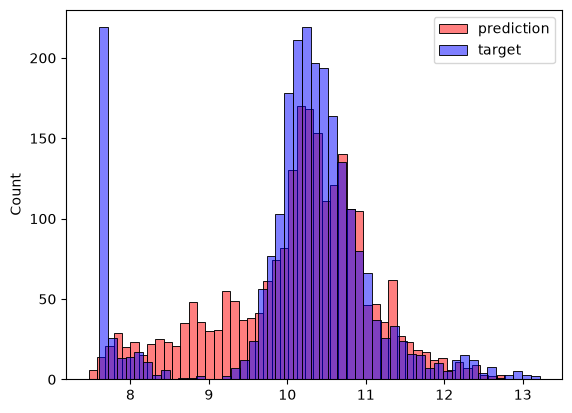

In [63]:
def prepare_x(df, base):
    df = df.copy()
    df['age'] = 2017 - df['year']
    features = base + ['age']
    return df[features].fillna(0).values

# build baseline model on selected numeric features
base = ['engine_hp', 'engine_cylinders', 'highway_mpg', 'city_mpg', 'popularity']

X_train = prepare_x(df_train, base)
w_0, w = train_linear_regression(X_train, y_train)

X_val = prepare_x(df_val, base)
y_pred = w_0 + X_val.dot(w)
print("RMSE: ", rmse(y_val, y_pred))

sns.histplot(y_pred, label='prediction', color='red', alpha=0.5, bins=50)
sns.histplot(y_val, label='target', color='blue',  alpha=0.5, bins=50)
plt.legend()

### Part 11: Categorical Variables

Categorical variables represent groups such as `make`, `transmission_type`, or `number_of_doors`. Since ML models need numbers, categories are encoded as **binary columns** (one-hot encoding):

| doors | doors_2 | doors_3 | doors_4 |
| ----- | ------: | ------: | ------: |
| 2     |       1 |       0 |       0 |
| 3     |       0 |       1 |       0 |
| 4     |       0 |       0 |       1 |

Adding useful categorical features can improve the model, but adding many correlated binary features can make linear regression unstable and produce extremely large weights. This leads into **regularization**.

In [64]:
categorical_columns = [
    'make', 'model', 'engine_fuel_type', 'driven_wheels', 'market_category',
    'vehicle_size', 'vehicle_style']

categorical = {}

for c in categorical_columns:
    categorical[c] = list(df_train[c].value_counts().head().index)

categorical

{'make': ['chevrolet', 'ford', 'volkswagen', 'toyota', 'dodge'],
 'model': ['silverado_1500', 'tundra', 'f-150', 'sierra_1500', 'tacoma'],
 'engine_fuel_type': ['regular_unleaded',
  'premium_unleaded_(required)',
  'premium_unleaded_(recommended)',
  'flex-fuel_(unleaded/e85)',
  'diesel'],
 'driven_wheels': ['front_wheel_drive',
  'rear_wheel_drive',
  'all_wheel_drive',
  'four_wheel_drive'],
 'market_category': ['crossover',
  'flex_fuel',
  'luxury',
  'hatchback',
  'luxury,performance'],
 'vehicle_size': ['compact', 'midsize', 'large'],
 'vehicle_style': ['sedan',
  '4dr_suv',
  'coupe',
  'convertible',
  '4dr_hatchback']}

In [65]:
def prepare_x(df, base):
    """
    Prepares a feature matrix for linear regression.

    Creates the engineered feature `age` and one-hot encoded columns
    for number of doors and car make.

    Parameters:
        df (DataFrame): Input data.
        base (list): Base numerical features to include.

    Returns:
        ndarray: Prepared feature matrix with missing values filled with 0.
    """
    df = df.copy()
    df['age'] = 2017 - df['year']
    features = base + ['age']

    for v in [2, 3, 4]:
        # to get any one-hot encoded categorical data column
        # (df_train.number_of_doors == 3).astype('int')
        df['num_doors_%s' % v] = (df.number_of_doors == v).astype(int)
        features.append('num_doors_%s' % v)

    # create category column
    makes = list(df.make.value_counts().head().index)
    for v in makes:
        df['make_%s' % v] = (df.make == v).astype(int)
        features.append('make_%s' % v)

    return df[features].fillna(0).values

def prepare_x_allcat(df, base, categorical):
    """
    Prepares a feature matrix using numerical and categorical features.

    Creates the engineered feature `age` and one-hot encodes all
    categories defined in `categorical`.

    Parameters:
        df (DataFrame): Input data.
        base (list): Base numerical features to include.
        categorical (dict): Selected categorical columns with values

    Returns:
        ndarray: Prepared feature matrix with missing values filled with 0.
    """
    df = df.copy()
    df['age'] = 2017 - df['year']
    features = base + ['age']

    for name, values in categorical.items():
        for value in values:
            df['%s_%s' % (name, value)] = (df[name] == value).astype(int)
            features.append('%s_%s' % (name, value))

    return df[features].fillna(0).values

In [66]:
# build baseline model on selected numeric features
base = ['engine_hp', 'engine_cylinders', 'highway_mpg', 'city_mpg', 'popularity']

X_train = prepare_x(df_train, base)
w_0, w = train_linear_regression(X_train, y_train)
print("bias: ", w_0)
print("w: ", w)

X_val = prepare_x(df_val, base)
y_pred = w_0 + X_val.dot(w)
print("RMSE for make and door#: ", rmse(y_val, y_pred))

bias:  10.678698340689163
w:  [ 3.45701060e-03  9.17408538e-02 -6.18372418e-03  1.23571673e-02
 -2.89616609e-05 -9.51811382e-02 -1.25096146e+00 -1.46396979e+00
 -1.29539677e+00 -1.95721851e-01 -7.92361383e-02  2.88307619e-02
 -2.87389672e-01 -2.83585754e-01]
RMSE for make and door#:  0.5076038849556633


In [67]:
X_train = prepare_x_allcat(df_train, base, categorical)
w_0, w = train_linear_regression(X_train, y_train)
print("bias: ", w_0)
print("w: ", w)

X_val = prepare_x_allcat(df_val, base, categorical)
y_pred = w_0 + X_val.dot(w)
print("RMSE for all cat: ", rmse(y_val, y_pred))

bias:  -24.98064787452455
w:  [ 9.08758792e-02 -6.87717921e+00 -4.14086619e-01  6.30326090e-02
 -4.06149991e-05 -2.49553615e-01  1.26198066e+00  3.50216850e+00
 -2.41717210e+00  3.56043073e+00 -9.55197301e-01 -1.01094583e+01
 -1.47924235e+01 -1.11294220e+00  4.66279627e+00 -2.41660502e+01
 -1.00764359e+01 -8.63998625e+00 -1.80792255e+01 -1.64940064e+01
 -5.13424804e+00 -2.88797480e+01 -3.66481947e+01 -1.65232991e+01
 -1.65781579e+01 -6.34842268e-02  8.43129133e+00  1.50203686e+01
 -1.95655901e+01  6.67515540e+00  3.52751268e+01  1.24254951e+01
  1.91836899e+01 -4.19856999e-02  7.44286419e-02  1.55923729e-02
  2.05638710e-01 -1.32443956e-01]
RMSE for all cat:  77.8932784562492


Using all categorical dummy variables creates redundant/highly correlated features, making the solution unstable, so regularization is needed to stabilize the weights and prevent extreme predictions.

### Part 12: Regularization

A matrix is invertible only if its columns are linearly independent. If two columns are the same, one is redundant, so the matrix becomes singular and has no inverse. When features are duplicated or highly correlated, $X^TX$ can become singular or unstable, causing very large weights and poor predictions (as in the last example).
Regularization fixes this by adding a small value $\alpha$ to the diagonal:

$\boxed{w=(X^TX+\alpha I)^{-1}X^Ty}$
where:

- $\alpha$ = regularization strength
- $I$ = identity matrix

This makes the solution more stable and keeps weights from becoming extreme. The lesson uses Ridge regression.

In [68]:
# sample X matrix which has singular Gram matrix
X = np.array([
    [4, 4, 4],
    [3, 5, 5],
    [5, 1, 1],
    [5, 4, 4],
    [7, 5, 5],
    [4, 5, 5],
])

# singular gram matrix
XTX = X.T.dot(X)
print("XTX: ", XTX)

# try to get inverse
try:
    XTX_inv = np.linalg.inv(XTX)
except np.linalg.LinAlgError as e:
    print(e)

XTX:  [[140 111 111]
 [111 108 108]
 [111 108 108]]
Singular matrix


In [69]:
# sample X matrix which has invertible Gram matrix (columns are not same!)
X = np.array([
    [4, 4, 4],
    [3, 5, 5],
    [5, 1, 1],
    [5, 4, 4],
    [7, 5, 5],
    [4, 5, 6],
])

# singular gram matrix
XTX = X.T.dot(X)
print("XTX: ", XTX)

# try to get inverse
try:
    XTX_inv = np.linalg.inv(XTX)
    print("XTX_inv: ", XTX_inv)
except np.linalg.LinAlgError as e:
    print(e)

XTX:  [[140 111 115]
 [111 108 113]
 [115 113 119]]
XTX_inv:  [[ 0.041273   -0.10641472  0.0611636 ]
 [-0.10641472  1.70810542 -1.5191447 ]
 [ 0.0611636  -1.5191447   1.39184485]]


In [70]:
# sample Gram matrix which is not invertible, made invertible with adding small number diagonal
XTX = np.array([
    [1, 2, 2],
    [2, 1, 1],
    [2, 1, 1]
])

XTX_2 = XTX + 0.01 * np.eye(3)

# try to get inverse
try:
    XTX_inv = np.linalg.inv(XTX)
    print("XTX_inv: ", XTX_inv)
except np.linalg.LinAlgError as e:
    print(e)

# try to get inverse
try:
    XTX2_inv = np.linalg.inv(XTX_2)
    print("XTX2_inv: ", XTX2_inv)
except np.linalg.LinAlgError as e:
    print(e)

Singular matrix
XTX2_inv:  [[ -0.33668906   0.33501399   0.33501399]
 [  0.33501399  49.91540897 -50.08459103]
 [  0.33501399 -50.08459103  49.91540897]]


In [71]:
def train_linear_regression_reg(X, y, r=0.001):
    """
    Trains a regularized linear regression model using the normal equation.

    Regularization adds r to the diagonal of X.T @ X to stabilize
    the solution and prevent extremely large weights.

    Parameters:
        X (ndarray): Feature matrix.
        y (ndarray): Target values.
        r (float): Regularization strength.

    Returns:
        tuple:
            w0 (float): Bias/intercept.
            w (ndarray): Regularized feature weights.
    """
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX = XTX + r * np.eye(XTX.shape[0])

    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)
    
    return w_full[0], w_full[1:]

In [74]:
# build baseline model on selected numeric features
base = ['engine_hp', 'engine_cylinders', 'highway_mpg', 'city_mpg', 'popularity']

X_train = prepare_x_allcat(df_train, base, categorical)
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

# get the weights
w_0, w = train_linear_regression_reg(X_train, y_train, r=0.01)
print("bias: ", w_0)
print("w: ", w)

X_val = prepare_x_allcat(df_val, base, categorical)
y_pred = w_0 + X_val.dot(w)
print("y_val shape:", y_val.shape)
print("y_pred shape:", y_pred.shape)
print("RMSE: ", rmse(y_val, y_pred))

X_train shape: (7150, 38)
y_train shape: (7150,)
bias:  6.449692337575782
w:  [ 2.12427389e-03  1.17801494e-01 -4.46609800e-03  7.04757689e-03
 -5.94036594e-05 -9.94626338e-02 -6.38681788e-02  1.77538943e-01
  9.96981045e-03 -7.06612071e-03 -1.53342789e-01 -2.56653636e-01
 -5.61309741e-01 -2.41784492e-01 -3.34021292e-01 -2.46513552e-01
 -6.57402482e-01 -1.57473668e-01 -5.68901479e-01 -7.40485153e-01
 -3.33288406e-01  1.62715299e+00  1.56558495e+00  1.64466795e+00
  1.61228644e+00 -4.31963204e-02  1.36990079e-01  1.81217843e-02
 -8.24216114e-02 -5.94896714e-03  2.18571299e+00  2.11739347e+00
  2.14658587e+00 -4.19774418e-02  7.45020769e-02  1.55536604e-02
  2.05647191e-01 -1.32476299e-01]
y_val shape: (2382,)
y_pred shape: (2382,)
RMSE:  0.46520983003298655


With regularization, using all categorical features provides better training.

### Part 13: Tuning the Model

Model tuning means choosing the best hyperparameter using the validation set.

For regularized linear regression, try different values of the regularization parameter (r), compute validation RMSE for each, and select the value with the lowest RMSE. Then retrain the model using the chosen (r).

In [76]:
# train for different regularization parameters
for r in [0.0, 0.00001, 0.0001, 0.001, 0.1, 1, 10]:
    X_train = prepare_x_allcat(df_train, base, categorical)
    w_0, w = train_linear_regression_reg(X_train, y_train, r=r)

    X_val = prepare_x_allcat(df_val, base, categorical)
    y_pred = w_0 + X_val.dot(w)
    score = rmse(y_val, y_pred)
    
    print(f"r: {r} | Bias: {w_0} | RMSE: {score}")

r: 0.0 | Bias: -24.98064787452455 | RMSE: 77.8932784562492
r: 1e-05 | Bias: 6.451461044259562 | RMSE: 0.465205574016889
r: 0.0001 | Bias: 6.451443075471321 | RMSE: 0.4652056047992121
r: 0.001 | Bias: 6.451283854178069 | RMSE: 0.4652059856952217
r: 0.1 | Bias: 6.43390145039535 | RMSE: 0.4652508186608697
r: 1 | Bias: 6.287349474347586 | RMSE: 0.46587711794546427
r: 10 | Bias: 5.411185220968775 | RMSE: 0.4790484883414095


In [77]:
# train with the best one (0.00001)
r = 0.00001
X_train = prepare_x_allcat(df_train, base, categorical)
w_0, w = train_linear_regression_reg(X_train, y_train, r=r)

X_val = prepare_x_allcat(df_val, base, categorical)
y_pred = w_0 + X_val.dot(w)
print("RMSE: ", rmse(y_val, y_pred))

RMSE:  0.465205574016889


### Part 14: Using the Model

After tuning, combine **train + validation** data and retrain the final model using the chosen hyperparameters.

Then evaluate once on the untouched **test set** to estimate final generalization performance. For a new observation:

1. Prepare its features in the same way as training data.
2. Predict with the final model.
3. If the target was log-transformed, convert it back with `expm1()`.

The test score should be reasonably close to the validation score.

In [79]:
# combine train and validation sets
df_full_train = pd.concat([df_train, df_val]).reset_index(drop=True)
X_full_train = prepare_x_allcat(df_full_train, base, categorical)
y_full_train = np.concatenate([y_train, y_val])

w_0, w = train_linear_regression_reg(X_full_train, y_full_train, r=0.00001)

# check rmse on test set
X_test = prepare_x_allcat(df_test, base, categorical)
y_pred = w_0 + X_test.dot(w)
score = rmse(y_test, y_pred)
print("RMSE: ", score)

RMSE:  0.46353434329457427


In [80]:
# use the model to predict the price of a particular car
car = df_test.iloc[20].to_dict()
X_car = prepare_x_allcat(pd.DataFrame([car]), base, categorical)
y_pred = w_0 + X_car.dot(w)
y_pred = y_pred[0]

print("Predicted price:", np.expm1(y_pred))
print("Actual price:", np.expm1(y_test[20]))

Predicted price: 38189.58330682329
Actual price: 35000.00000000001


### Part 15: 